In [1]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import scipy.stats as sts
import astropy.units as u
from astropy.constants import G,M_sun,kpc
from matplotlib.lines import Line2D
from matplotlib.legend import Legend
import matplotlib.colors as mcol
import matplotlib.cm as mcm
from matplotlib import ticker
import scipy.optimize as sopt
import h5py
from sim_read import *

plt.rcParams["axes.linewidth"]  = 2
plt.rcParams["xtick.major.size"]  = 8
plt.rcParams["xtick.minor.size"]  = 3
plt.rcParams["ytick.major.size"]  = 8
plt.rcParams["ytick.minor.size"]  = 3
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams.update({'font.size': 24})
plt.rcParams.update({'font.family': 'serif'})
plt.rcParams["mathtext.default"] = 'rm'
plt.rcParams["mathtext.fontset"] = 'cm'

In [8]:
gls = sim(exsub_fields=['SubhaloMass','SubhaloHalfmassRadType'])
sim.mass_add(gls)

In [9]:
massive_gal,dwarf_gal = dwf_select(gls.sub.mst)
all_gal = np.array([*dwarf_gal,*massive_gal])

sfms_intercept,sfms_slope = dwf_sfms(gls.sub.mst,gls.sub.ssfr)

dconv = 1.428571429e-3
kang = (180*3600)/np.pi
dhalfbox = 25.0
dview = 50.0

def elves_Re(M,a=1.077,b=0.246): return a + b*M
def app_mag(Mag,D): return Mag + 5*(np.log10(D)+5)
def sfb_mag(Mag,D,Re): return app_mag(Mag,D) + 2.5*np.log10(np.pi*np.square(kang*Re/D))

1494 10829
1494 10829
-8.346120696830761 -0.17679571397785238


In [4]:
h0 = 0.677
dconv = 1e-3/h0
mconv = 10 - np.log10(h0)

def samp_selc(floor=7.5,thresh=9.5,NN=5):
    massive_gal,dwarf_gal = dwf_select(gls.sub.mst,thresh,floor)
    all_gal = np.array([*dwarf_gal,*massive_gal])
    
    rh0 = len(all_gal)/50.0**3
    print(len(all_gal),rh0)

    back_gal = backspl_load()

    dhost = [[],[],[]]
    llg,llt,llh,llr = [[],[],[]],[[],[],[]],[[],[],[]],[[],[],[]]

    all_gal_tree =  KDTree(gls.sub.SubhaloPos[all_gal,:]) 
    massive_gal_tree = KDTree(gls.sub.SubhaloPos[massive_gal,:]) 

    for j in back_gal:
        lh = gls.sub.SubhaloGrNr[j]
        if gls.hst.group_m200[lh]>=10 and gls.hst.group_m200[lh]<11.5 and gls.sub.mst[j]<thresh and gls.sub.mst[j]>floor:
                dist, ind = massive_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                ind = massive_gal[ind]
                dist *= dconv
                MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind[1:]])
                          
                dhost[2].append(dist[1])
                llt[2].append(max(MD_mass - 3*np.log10(dist[1:])) - 10.96)
                llh[2].append(lh)
                llg[2].append(j)
                    
                dist0, ind0 = all_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                dist0 *= dconv
                llr[2].append(0.2387324146*(NN+1)/dist0[-1]**3)

        #dwarf_gal = np.delete(dwarf_gal,np.where(dwarf_gal==j)[0])

    all_gal = np.array(list(set(all_gal)-set(back_gal)))
    all_gal_tree =  KDTree(gls.sub.SubhaloPos[all_gal,:]) 
    
    dwarf_host,host_mem = np.unique(gls.sub.SubhaloGrNr[dwarf_gal],return_inverse=True)
    Ndh = len(dwarf_host)
    for i in range(Ndh):  
        lh = dwarf_host[i]
        #print(gls.hst.group_m200[lh])
        if gls.hst.group_m200[lh]>=10 and gls.hst.group_m200[lh]<11.5:
            dw_mem = dwarf_gal[np.where(host_mem==i)[0]]

            #r = wrap_dist_1n(gls.sub.SubhaloPos[cen,:],gls.hst.GroupPos[lh,:])
            if len(dw_mem)>=1:
                stellar_sort = np.argsort(gls.sub.mst[dw_mem])
                cen = dw_mem[stellar_sort[-1]]
            
                dist, ind = massive_gal_tree.query(gls.sub.SubhaloPos[cen,:], k=NN+1)
                ind = massive_gal[ind]
                dist *= dconv
                MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind[1:]])

                dhost[0].append(dist[1])
                llt[0].append(max(MD_mass - 3*np.log10(dist[1:])) - 10.96)
                llh[0].append(lh)
                llg[0].append(cen)
                
                dist0, ind0 = all_gal_tree.query(gls.sub.SubhaloPos[cen,:], k=NN+1)
                dist0 *= dconv
                llr[0].append(0.2387324146*(NN+1)/dist0[-1]**3)

                if len(dw_mem)>1:
                    for j in dw_mem[stellar_sort[:-1]]:
                        dist, ind = massive_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                        ind = massive_gal[ind]
                        dist *= dconv
                        MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind[1:]])
    
                        dhost[1].append(dist[1])
                        llt[1].append(max(MD_mass - 3*np.log10(dist[1:])) - 10.96)
                        llh[1].append(lh)
                        llg[1].append(j)
    
                        dist0, ind0 = all_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                        dist0 *= dconv
                        llr[1].append(0.2387324146*(NN+1)/dist0[-1]**3)
                    
        
    return llt,llh,llg,llr,dhost



In [5]:
llt,llh,llg,llr,dhost = samp_selc(thresh=9.5,floor=8.0)

N_lll = [len(llh[k]) for k in range(3)]
print(N_lll)
bin_mk = ['o','D','s']
print(N_lll[0]+N_lll[1]+N_lll[2])

1494 6413
7907 0.063256
1257
[3321, 216, 144]
3681


In [6]:
llg_a = np.array([m for i in range(3) for m in llg[i]])
mst_a = np.array([m for i in range(3) for m in gls.sub.mst[llg[i]]])
llt_a = np.array([t for i in range(3) for t in llt[i]])
llh_a = np.array([h for i in range(3) for h in llh[i]])
dhost_a = np.array([d for i in range(3) for d in dhost[i]])
m200_a = gls.hst.group_m200[llh_a]
ssfr_a = np.array([s for i in range(3) for s in gls.sub.ssfr[llg[i]]])
dsfms_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))
llr_a = np.log10(np.array([r for i in range(3) for r in llr[i]])) - np.log10(0.142904)

x_a = np.array([x for i in range(3) for x in gls.sub.SubhaloPos[llg[i],0]])*dconv - dhalfbox
y_a = np.array([x for i in range(3) for x in gls.sub.SubhaloPos[llg[i],1]])*dconv - dhalfbox
z_a = np.array([x for i in range(3) for x in gls.sub.SubhaloPos[llg[i],2]])*dconv - dhalfbox + dview

In [12]:
hf = h5py.File('./suppl/stellar_sizes_099.hdf5', 'r') 

#subid = np.copy(hf.get('id_subhalo')).astype(int)
Rhalf = np.copy(hf.get('Rhalf')).astype(float)
hf.close()

print(Rhalf[-1,0,dwarf_gal])

Re_g = 3+np.log10(Rhalf[-1,6,llg_a]) 
M_g = gls.sub.SubhaloStellarPhotometrics[llg_a,4]

R_hst = np.log10(gls.sub.SubhaloHalfmassRadType[llg_a,4]/h0) +3

[ 3.99623632  2.42610765  2.78087258 ... -1.         -1.
 -1.        ]


Text(0, 0.5, '$Dwarf\\ log(R_e/{\\rm pc})$')

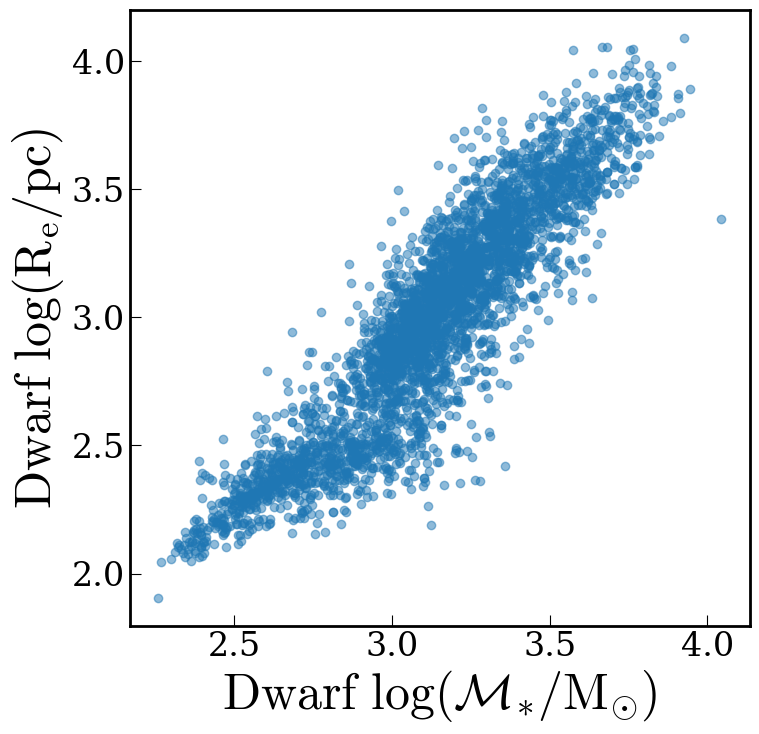

In [13]:
fig,ax=plt.subplots(figsize=(8,8))

mst_bins = np.arange(7.5,9.5,0.05)

ax.plot(R_hst,Re_g,ls='none',marker='o',alpha=0.5)
#ax.plot(mst_bins,elves_Re(mst_bins),ls='--',lw=3,color='black',alpha=0.8)

ax.set_xlabel(r'$Dwarf\ log(\mathcal{M}_{\ast}/M_{\odot})$',fontsize=36)
ax.set_ylabel(r'$Dwarf\ log(R_e/{\rm pc})$',fontsize=36)


3680 3680


(22.0, 26.371296188670545)

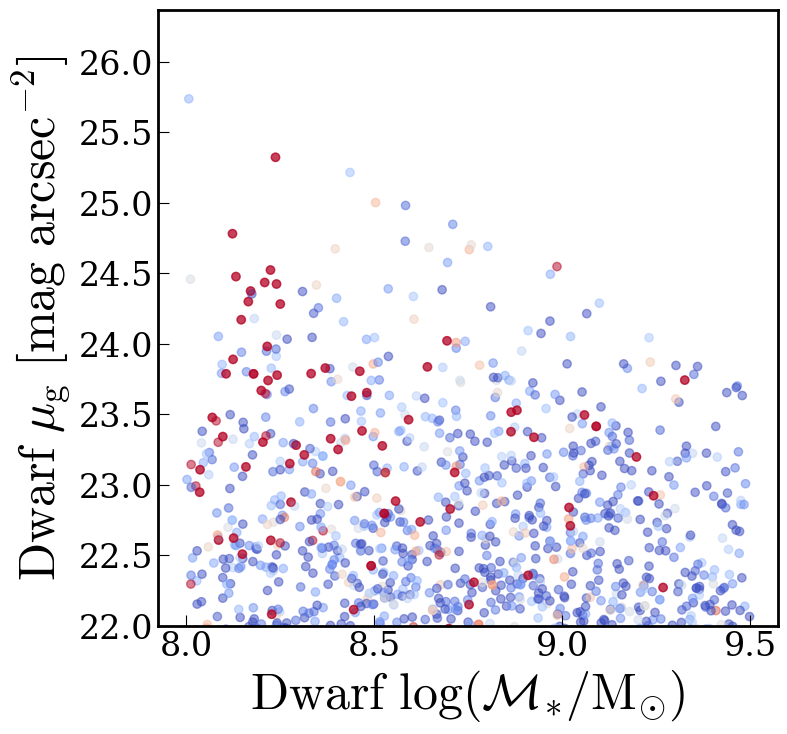

In [39]:
fig,ax=plt.subplots(figsize=(8,8))
dist = np.sqrt(np.square(x_a)+np.square(y_a)+np.square(z_a))
mu_g = sfb_mag(M_g,dist,np.power(10,Re_g-6))
print(len(M_g),len(dist))

lsbg = np.where(mu_g>24.0)[0]

ax.scatter(mst_a,mu_g,c=dsfms_a,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.5)

ax.set_ylabel(r'$Dwarf\ \mu_g\ [{\rm mag\ arcsec^{-2}}]$',fontsize=36)
ax.set_xlabel(r'$Dwarf\ log(\mathcal{M}_{\ast}/M_{\odot})$',fontsize=36)

ax.set_ylim(bottom=22)


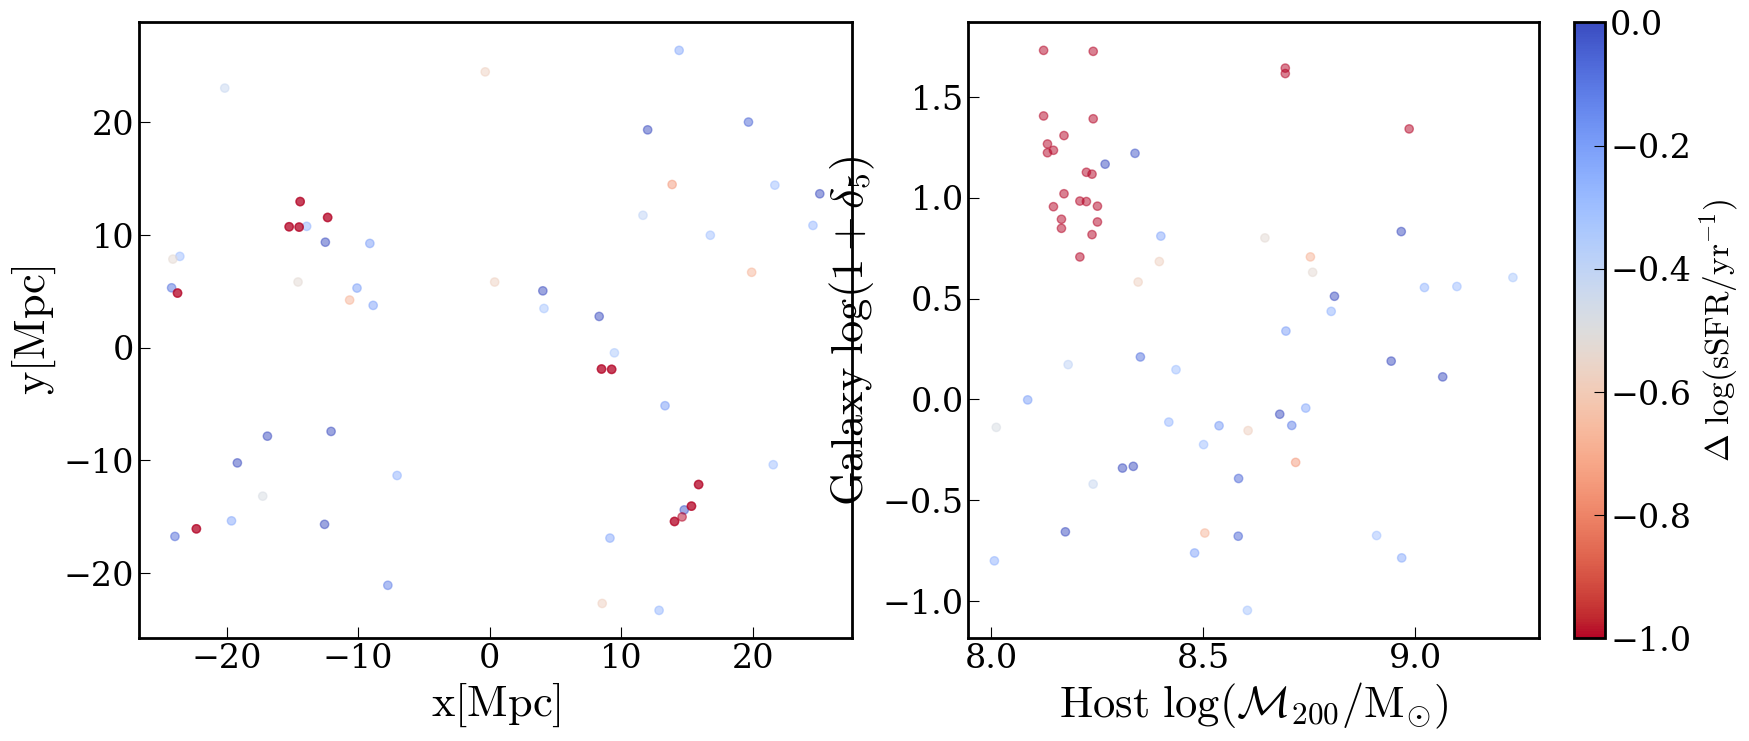

In [40]:
fig,ax=plt.subplots(1,4,figsize=(20,8),width_ratios=[0.46,0.075,0.46,0.005])

##mdyn_a = 10.155 + np.log10( np.array([gls.sub.SubhaloMass[h] for i in range(3) for h in llg[i]]))
#qnc_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))
#mag_samp = np.where((mst_a<9.5)&(qnc_a>1))[0]


ax[0].scatter(x_a[lsbg],y_a[lsbg],marker='o',c=dsfms_a[lsbg],cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.5)

ax[0].set_xlabel(r'$x[Mpc]$',fontsize=32)
ax[0].set_ylabel(r'$y[Mpc]$',fontsize=32)

ax[2].scatter(mst_a[lsbg],llr_a[lsbg],c=dsfms_a[lsbg],cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.5)
#ax[2].scatter(m200_a[dw_samp],llr_a[dw_samp],c='none',edgecolors='black',marker='o',linewidth=0.5,alpha=0.2)

#ax[2].axvline(11.5,color='black')
#ax[2].axhline(2,color='black',ls='--')

ax[2].set_ylabel(r'$Galaxy\ log(1+\delta_5)$',fontsize=32)
ax[2].set_xlabel(r'$Host\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=32)

ax[1].set_axis_off()
ax[3].set_axis_off()

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax[2], orientation='vertical',label=r'$\Delta\ log(sSFR/yr^{-1})$')

ax[0].set_rasterized(True)
ax[2].set_rasterized(True)
plt.subplots_adjust(wspace=0.0)
#plt.savefig('dens_mapv2.pdf',bbox_inches='tight')


In [9]:
host_bins = [np.where(llm==1)[0],np.where((llm>1))[0]]
bin_cols = ['royalblue','crimson']
bin_mk = ['o','D','s']
print(len(host_bins[0]),len(host_bins[1]))


6452 641


In [6]:
#def VLupton(g): return g - 0.2906*(u - g) + 0.0885;  sigma = 0.0129
def linear(x,a,b): return a*x + b
def tully_fit(x,a,b,c): return np.multiply(x,a) - 0.4343*np.power(10,b-x) + c

def most(M,M1,A,beta,gamma): 
    return A + M1 - np.log10(np.power(10,-beta*(M-M1))+np.power(10,gamma*(M-M1)))

mbin = np.linspace(10,11.5,21)

In [21]:
print(np.shape(sub_halos['SubhaloVel'][llg[i],:]-host_halos['GroupVel'][llh[i],:]))
print(np.shape(np.transpose(sub_halos['SubhaloPos'][llg[i],:]-host_halos['GroupPos'][llh[i],:])))

(26, 3)
(3, 26)
